# Explainable AI (XAI): Abriendo la Caja Negra con SHAP y LIME


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/90_casos_estudio/interpretabilidad_modelos_shap.ipynb)


## Objetivos del Caso de Estudio


- **Perspectiva de Negocio y Legal:** Comprender el "Derecho a la Explicación" (GDPR) y por qué desplegar modelos de caja negra en sectores críticos (salud, finanzas) es un riesgo inaceptable.
- **Perspectiva de Ingeniería:** Superar las limitaciones del *Feature Importance* tradicional (Gini) que no ofrece direccionalidad ni explicaciones a nivel individual.
- **Implementación de SHAP:** Aplicar la Teoría de Juegos Cooperativos para obtener explicaciones matemáticas exactas, tanto globales (cómo funciona el modelo) como locales (por qué se tomó una decisión específica).
- **Implementación de LIME:** Utilizar aproximaciones lineales locales para explicar cualquier modelo de forma agnóstica y rápida.



## Prerrequisitos


- Entendimiento de modelos basados en árboles y ensamblados (XGBoost / Random Forest).
- Haber completado: [Ensamblado de Modelos: Bagging y Boosting](../03_machine_learning/08_ensamblado_de_modelos.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

    # Instalamos las librerías de explicabilidad y XGBoost
    subprocess.run(["pip", "install", "shap", "lime", "xgboost"], check=True)
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## 1. Introducción: El Fin de la Caja Negra


Imaginemos que entrenamos un modelo XGBoost con un 95% de *Recall* para predecir Accidentes Cerebrovasculares (ACV). Llevamos el modelo al hospital y el sistema marca a un paciente de 45 años como "Alto Riesgo".

El médico pregunta: *"¿Por qué? Su nivel de glucosa es normal y no fuma"*.
Si nuestra respuesta es: *"No sé, el modelo multiplicó 500 árboles de decisión y el resultado dio `0,85`"*, el médico directamente apagará el sistema. No puede dar un diagnóstico con confianza sin saber porqué... En medicina y finanzas, **la precisión sin confianza es inútil**.

Además, regulaciones como el GDPR (*RGPD o GDPR, por sus siglas en inglés. Reglamento General de Protección de Datos*) en Europa exigen que cualquier decisión automatizada que afecte a un humano pueda ser explicada de forma comprensible.

### Preparando el Modelo (XGBoost)



Vamos a cargar nuestro dataset de ACV, preprocesarlo y entrenar un modelo complejo (XGBoost) que actuará como nuestra "caja negra".



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1. Carga de datos
dataset_path = "datasets/acv/datos_acv.csv"
df = load_dataset(dataset_path)
df = df.drop(columns=['id'])

X = df.drop(columns=['apoplejia'])
y = df['apoplejia']

# 2. Preprocesamiento (Imputación y Codificación Ordinal para mantener los nombres de las columnas legibles en SHAP)
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocesador = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), cat_cols)
], remainder='passthrough')

# Transformamos los datos y recuperamos los nombres de las columnas para la explicabilidad
X_proc = pd.DataFrame(preprocesador.fit_transform(X), columns=num_cols + cat_cols)
X_train, X_test, y_train, y_test = train_test_split(X_proc, y, test_size=0.2, random_state=42, stratify=y)

# 3. Entrenamos la "Caja Negra" (XGBoost)
# scale_pos_weight maneja el desbalance extremo de este dataset
modelo_xgb = xgb.XGBClassifier(n_estimators=100, max_depth=4, scale_pos_weight=20, random_state=42)
modelo_xgb.fit(X_train, y_train)

print("Modelo XGBoost entrenado exitosamente.")

Dataset cargado exitosamente con 5110 filas y 12 columnas.
Modelo XGBoost entrenado exitosamente.



---



## 2. La Ilusión del *Feature Importance* Tradicional


La mayoría de los ingenieros intentan explicar sus modelos usando el atributo `.feature_importances_` (basado en la reducción de impureza Gini). Veamos qué nos dice:

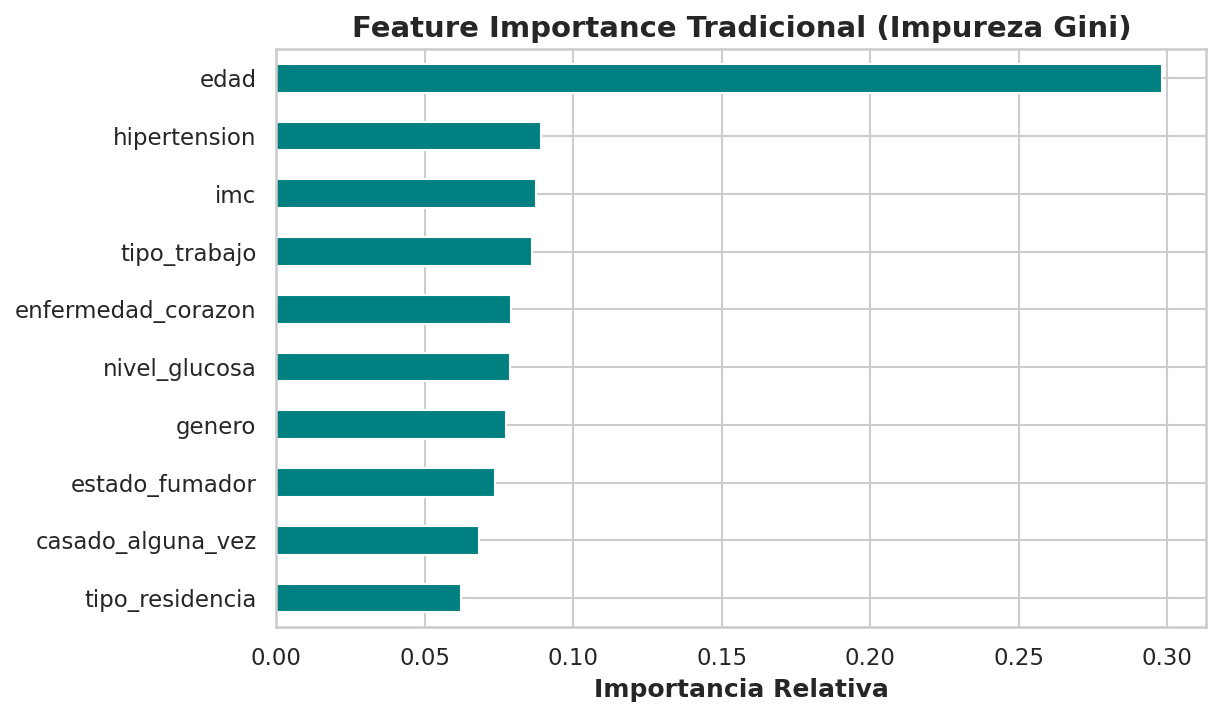

In [4]:
# Extraemos la importancia tradicional (Gini)
importancias_gini = pd.Series(modelo_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importancias_gini.plot(kind='barh', color='teal')
plt.title("Feature Importance Tradicional (Impureza Gini)")
plt.xlabel("Importancia Relativa")
plt.show()


**⚠️ Alerta: Las 3 fallas del Gini**
1. **No tiene direccionalidad:** El gráfico nos dice que la `edad` es importante. Pero, ¿ser mayor aumenta o disminuye el riesgo de ACV? El Gini no te lo dice.
2. **Sesgo de Cardinalidad:** Tiende a darle más importancia a variables continuas (como el IMC) simplemente porque el árbol puede hacer más cortes matemáticos en ellas, no porque sean realmente más predictivas.
3. **Es Global, no Local:** Te explica cómo funciona el modelo en general, pero no te sirve para explicarle al médico por qué *este paciente en particular* fue clasificado como riesgo.


## 3. SHAP: Teoría de Juegos aplicada al Machine Learning



Para resolver esto, usamos **SHAP** (*SHapley Additive exPlanations*).

**La Intuición:**  
Imaginemos que el modelo es una empresa y las variables (Edad, Glucosa, Fumar) son los empleados. La empresa acaba de ganar `$100.000` (la predicción de riesgo). ¿Cómo repartimos ese dinero de forma justa entre los empleados según lo que aportó cada uno?  
SHAP utiliza la Teoría de Juegos Cooperativos (Premio Nobel de Economía) para calcular el aporte marginal exacto de cada variable a la predicción final.

### Explicabilidad Global: El Gráfico Beeswarm



Vamos a calcular los valores SHAP para todo nuestro *Test Set* y generar uno de los gráficos más poderosos del Machine Learning moderno.

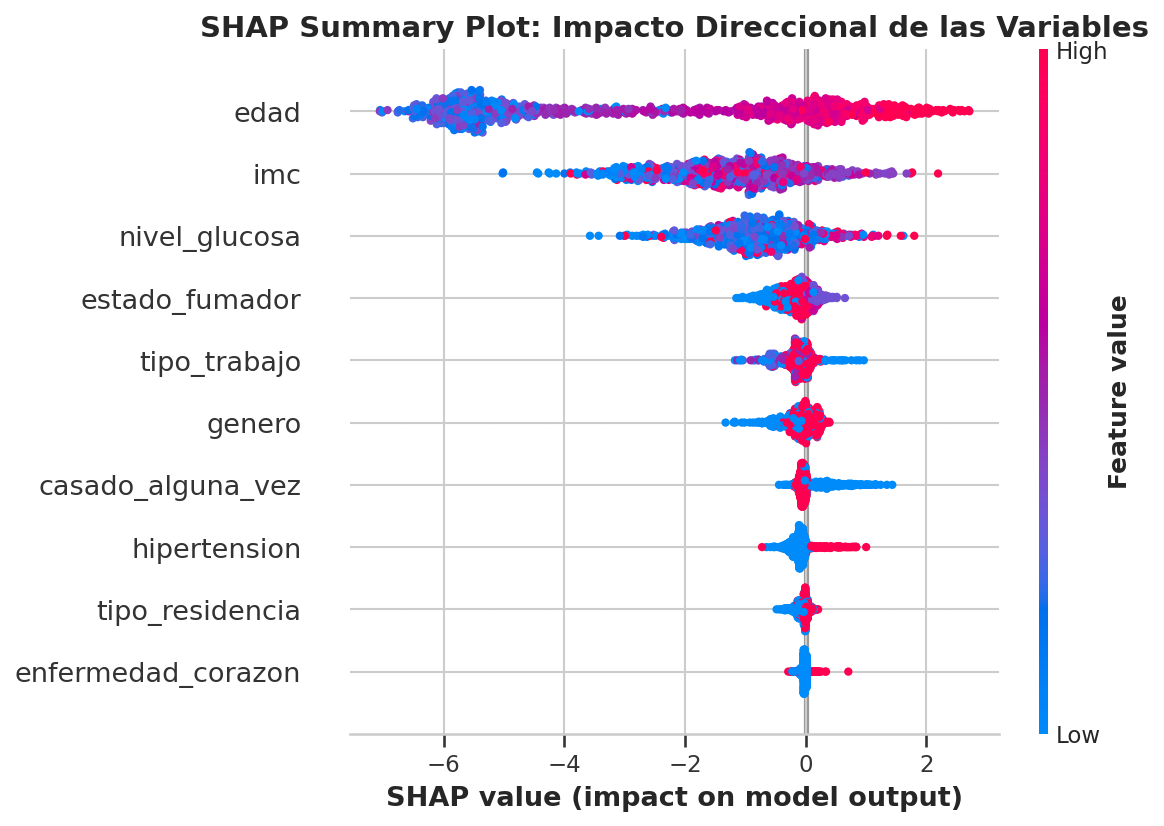

In [5]:
import shap

# Inicializamos el entorno de JavaScript para gráficos interactivos
shap.initjs()

# 1. Creamos el "Explicador" optimizado para árboles (TreeExplainer es rapidísimo)
explainer_shap = shap.TreeExplainer(modelo_xgb)

# 2. Calculamos los valores SHAP para el Test Set
shap_values = explainer_shap.shap_values(X_test)

# 3. Generamos el Gráfico Resumen (Beeswarm)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot: Impacto Direccional de las Variables", fontsize=14)
plt.show()

### Análisis: Leyendo el Gráfico SHAP


Este gráfico reemplaza por completo al Gini. ¿Cómo se lee?
- **Eje Y:** Las variables ordenadas por importancia real.
- **Eje X (SHAP value):** El impacto en la predicción. Hacia la derecha (positivo) empuja al modelo a predecir "ACV". Hacia la izquierda (negativo) empuja a predecir "Sano".
- **Color:** El valor real del paciente. Rojo significa un valor alto (ej. mucha edad), Azul significa un valor bajo (ej. joven).

**Conclusiones Clínicas Extraídas:**
1. **Edad:** Los puntos rojos (personas mayores) están muy a la derecha. Ser mayor aumenta drásticamente el riesgo de ACV. Los puntos azules (jóvenes) están a la izquierda (protección).
2. **Nivel de Glucosa:** Los puntos rojos (glucosa alta) empujan fuertemente hacia la derecha.
3. **Direccionalidad Clara:** A diferencia del Gini, ahora podemos decirle al médico exactamente *cómo* cada variable afecta la salud del paciente.

### Explicabilidad Local: El Gráfico Waterfall (Cascada)



El médico no quiere ver un gráfico global; quiere ver el reporte del **Paciente #42**.  
SHAP nos permite desglosar una predicción individual partiendo desde el valor base (el promedio del dataset) hasta llegar a la predicción final del paciente.



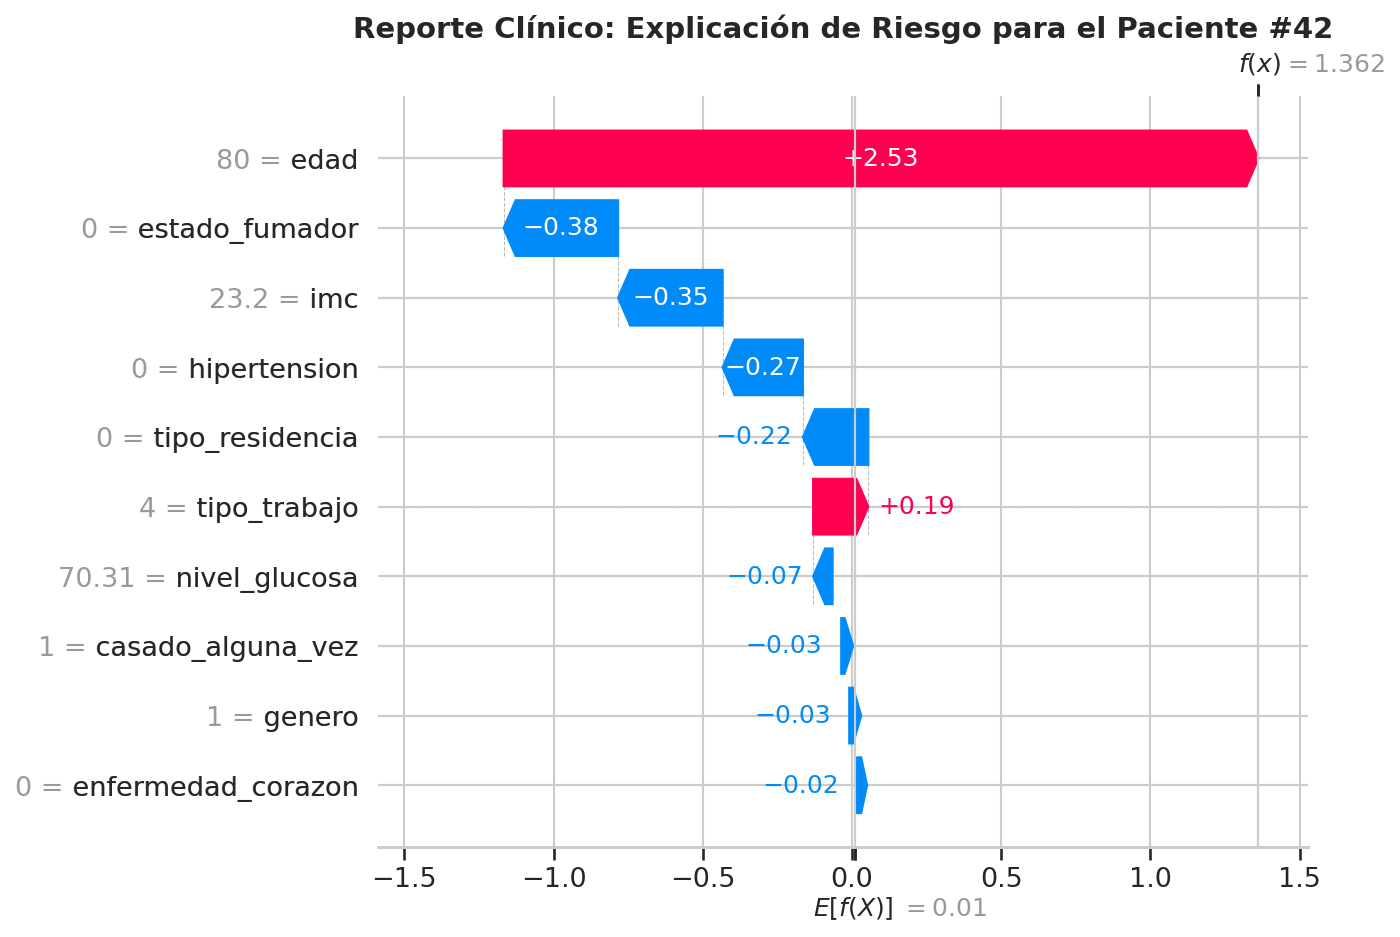

In [6]:
# Seleccionamos un paciente de alto riesgo del Test Set
paciente_idx = 42
paciente_datos = X_test.iloc[paciente_idx]

# Calculamos el valor SHAP específico (usando el objeto Explanation moderno)
shap_expl = explainer_shap(X_test)

# Generamos el gráfico de cascada para el Paciente #42
plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_expl[paciente_idx], max_display=10, show=False)
plt.title(f"Reporte Clínico: Explicación de Riesgo para el Paciente #{paciente_idx}")
plt.show()


**El Reporte para el Médico:**

*"El riesgo base de un paciente promedio en nuestro sistema es de apenas `0,01`. Sin embargo, este paciente tiene un riesgo altísimo (`1,36`). ¿Por qué? El factor crítico y absoluto es su avanzada edad: tener 80 años disparó su riesgo, sumando `+2,53` a la predicción.*

*Afortunadamente, el paciente tiene excelentes factores protectores: no fuma (resta `-0,38`), tiene un IMC saludable de 23,2 (resta `-0,35`), no tiene hipertensión (`-0,27`) y su nivel de glucosa es óptimo (70,31, restando `-0,07`). Aunque su estilo de vida es impecable y empuja la predicción hacia 'Sano' (barras azules), el peso matemático de sus 80 años es tan masivo que termina inclinando la balanza hacia un alto riesgo de ACV."*

**Qué significa todo esto?**: ¡Acabamos de convertir una caja negra matemática en un reporte clínico auditable!

### Descubriendo Relaciones No Lineales (Dependence Plot)



SHAP también nos permite descubrir interacciones complejas que el modelo aprendió por sí solo. Por ejemplo, ¿cómo interactúa la Edad con el Índice de Masa Corporal (IMC)?



<Figure size 1200x750 with 0 Axes>

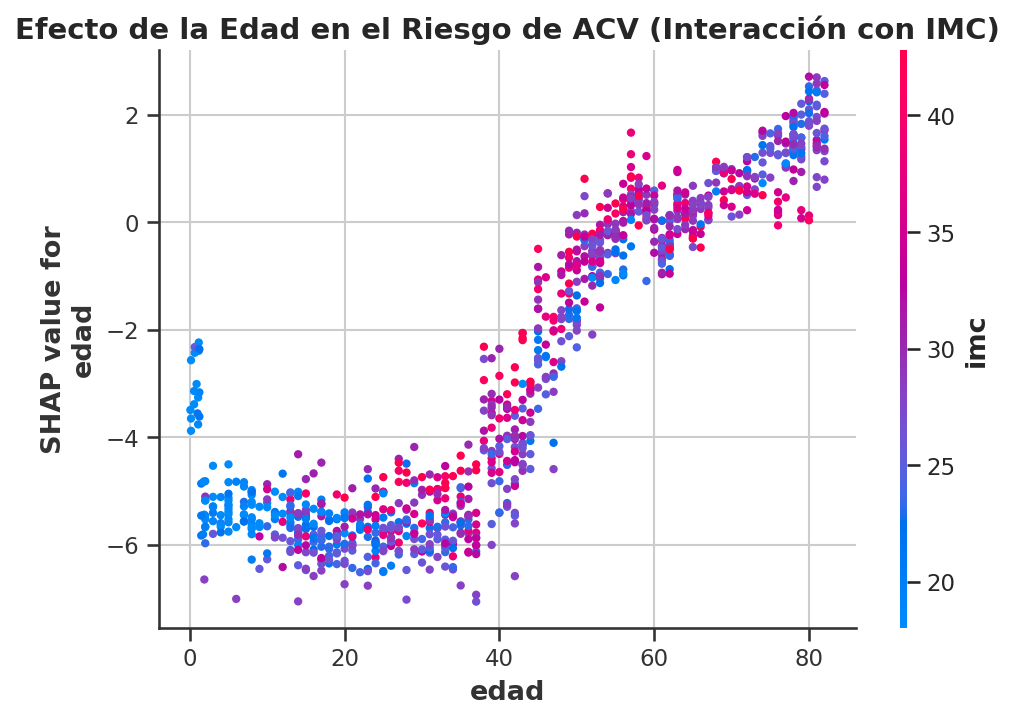

In [7]:
# Gráfico de Dependencia: Edad vs. Impacto SHAP, coloreado por IMC
plt.figure(figsize=(8, 5))
shap.dependence_plot("edad", shap_values, X_test, interaction_index="imc", show=False)
plt.title("Efecto de la Edad en el Riesgo de ACV (Interacción con IMC)")
plt.show()

*Criterio de Ingeniería:* Observar el eje X. El impacto en el riesgo (Eje Y) se mantiene negativo (protector) hasta los 40 años, momento en el cual cruza la línea del cero y se dispara exponencialmente hacia arriba. Además, apreciar en la dispersión vertical a una misma edad (por ejemplo, a los 60 años): los puntos se separan verticalmente formando un gradiente de colores. Esto nos demuestra visualmente que el modelo no usa la edad de forma aislada, sino que la combina con el IMC (los colores) para calcular el riesgo final de cada individuo.

## 4. LIME: Local Interpretable Model-agnostic Explanations


SHAP es matemáticamente perfecto, pero calcular los valores de Shapley es computacionalmente muy pesado. Para modelos de árboles existe `TreeExplainer` (que es rápido), pero si se usa una Red Neuronal o un SVM, SHAP puede tardar horas.

Aquí entra **LIME**.   
LIME es **Agnóstico al Modelo**. Trata al modelo como una caja negra absoluta.


**La Intuición:** Para explicar al Paciente #42, LIME genera cientos de pacientes falsos muy parecidos al Paciente #42, se los pasa a la caja negra, observa qué responde, y entrena un modelo lineal súper simple (como una Regresión Lineal) *solo en ese pequeño vecindario local*.

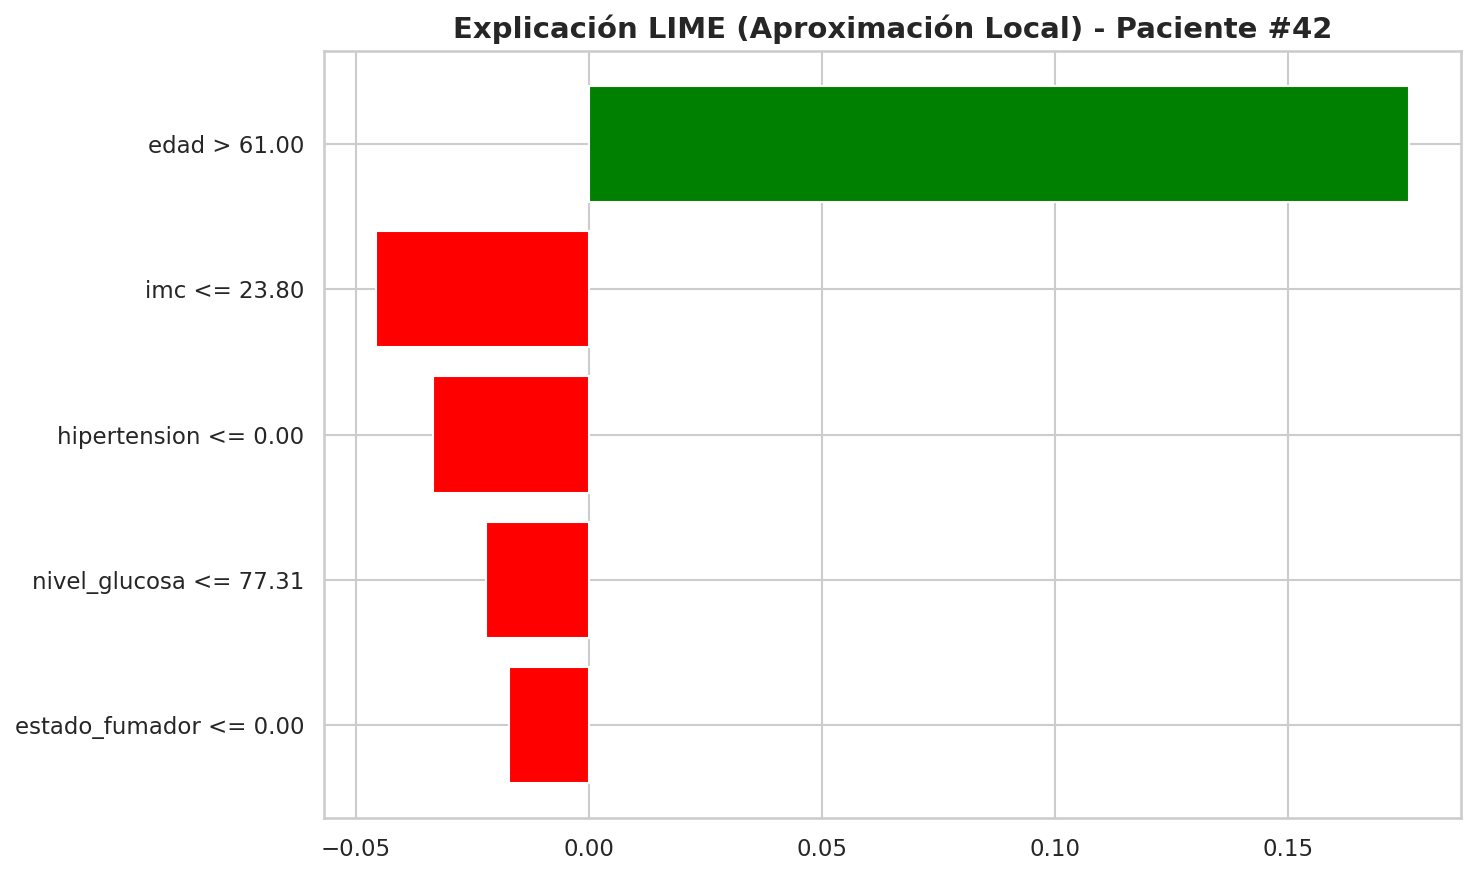

In [8]:
import lime
import lime.lime_tabular

# 1. Inicializamos el Explicador LIME
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Sano', 'Riesgo ACV'],
    mode='classification',
    random_state=42
)

# 2. Explicamos al mismo Paciente #42
# LIME necesita una función que devuelva probabilidades
predict_fn = lambda x: modelo_xgb.predict_proba(pd.DataFrame(x, columns=X_train.columns))

explicacion_lime = explainer_lime.explain_instance(
    data_row=X_test.iloc[paciente_idx].values,
    predict_fn=predict_fn,
    num_features=5 # Queremos las 5 variables más importantes para este paciente
)

# 3. Visualizamos
fig = explicacion_lime.as_pyplot_figure()
plt.title(f"Explicación LIME (Aproximación Local) - Paciente #{paciente_idx}")
plt.tight_layout()
plt.show()

**Análisis: SHAP vs LIME en la Práctica**

Observar el gráfico superior generado por LIME. Llega a la misma conclusión clínica que SHAP para este paciente, pero lo expresa de una manera mucho más digerible para un humano no técnico: mediante **reglas de corte**.  
LIME nos dice que el hecho de que la `edad > 61,00` es el factor principal que empuja hacia el riesgo de ACV (barra verde hacia la derecha). Por el contrario, tener un `imc <= 23,80`, no tener hipertensión (`<= 0,00`) y una `glucosa <= 77,31` son factores que empujan hacia la clase "Sano" (barras rojas hacia la izquierda).

**Criterio de Arquitectura**: LIME es excelente para crear explicaciones rápidas y fáciles de leer en un Dashboard comercial, ya que agrupa los valores continuos en rangos lógicos. Sin embargo, SHAP sigue siendo el estándar cuando se necesita precisión matemática exacta para una auditoría legal.

### SHAP vs. LIME: ¿Cuál elegir en Producción?



| Característica | SHAP | LIME |
| :--- | :--- | :--- |
| **Precisión Matemática** | Exacta (Teoría de Juegos). | Aproximada (Regresión Local). |
| **Velocidad** | Lento (excepto en Árboles con `TreeExplainer`). | Muy Rápido. |
| **Consistencia** | Siempre da el mismo resultado. | Puede variar si se corre dos veces (por el muestreo aleatorio). |
| **Uso en la Industria** | Reportes regulatorios, auditorías de sesgo, dashboards médicos. | APIs de alta concurrencia, explicaciones rápidas de texto/imágenes (va a ser muy útil en *deep learning*). |



## 5. Conclusión de Arquitectura MLOps


La explicabilidad no es un "extra" estético; es el puente entre la ingeniería de datos y la adopción del negocio.

Si se construye un modelo que predice la fuga de clientes (*Churn*), el equipo de retención no necesita saber que el cliente se va a ir; necesita saber **por qué** se va a ir para poder ofrecerle la promoción correcta. SHAP te da esa respuesta.

Al integrar SHAP en *Pipelines* de producción, podemos generar reportes PDF automatizados para cada predicción crítica, garantizando el cumplimiento del GDPR (si fuera el caso o necesidad) y ganando la confianza absoluta de los expertos del dominio (o dando pie a encontrar las razones para los casos problemáticos, y permitiendo así, realizar ajustes de manera informada).

## Referencias


1. Selbst, A. D., & Powles, J. (2017). *Meaningful information and the right to explanation*. [https://doi.org/10.1093/idpl/ipx022](https://doi.org/10.1093/idpl/ipx022)
1. Lundberg, S. M., & Lee, S. I. (2017). *A unified approach to interpreting model predictions*. [https://arxiv.org/abs/1705.07874](https://arxiv.org/abs/1705.07874)
2. Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why should i trust you?". [https://arxiv.org/abs/1602.04938](https://arxiv.org/abs/1602.04938)
3. [Documentación Oficial de SHAP](https://shap.readthedocs.io/)

---


## Entorno de Ejecución


In [9]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
PIL,11.3.0
anywidget,0.9.21
argparse,1.1
backcall,0.2.0
bottleneck,1.4.2
certifi,2026.2.25
